# Tutorial 7 · MLE, MAP & Bayesian Updating — Part B

**~40 minutes · after the worksheet**

Estimate a coin bias, update a Beta prior, and see regularization as prior information.

Work in pairs. Before each code cell, write down the qualitative result you expect. The notebook is designed to run top-to-bottom in a fresh kernel.


## 1 · Likelihood and posterior on one plot


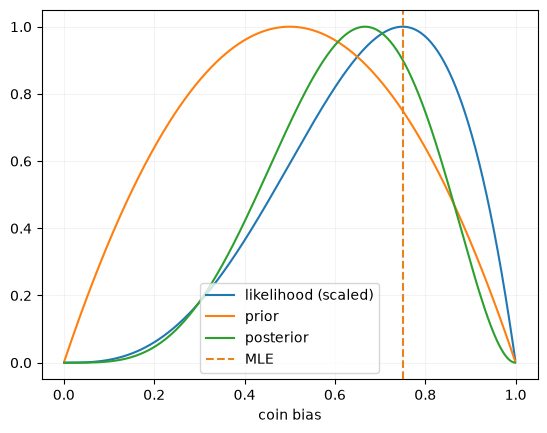

In [1]:
#| fig-alt: 'Scaled Bernoulli likelihood, Beta prior, and Beta posterior over the coin bias after three heads and one tail, with the MLE marked.'
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

theta = np.linspace(.001, .999, 600)
h, t = 3, 1
likelihood = theta**h * (1-theta)**t
prior = stats.beta(2, 2).pdf(theta)
posterior = stats.beta(2+h, 2+t).pdf(theta)
for y, label in [(likelihood/likelihood.max(), "likelihood (scaled)"), (prior/prior.max(), "prior"), (posterior/posterior.max(), "posterior")]:
    plt.plot(theta, y, label=label)
plt.axvline(h/(h+t), color="#EB811B", ls="--", label="MLE")
plt.legend(); plt.xlabel("coin bias"); plt.grid(alpha=.15);


## 2 · Stream flips and update online


In [2]:
flips = [1, 1, 0, 1, 0, 1, 1, 1]
a, b = 2, 2
for n, flip in enumerate(flips, 1):
    a += flip; b += 1-flip
    print(n, f"Beta({a},{b})", "mean", round(a/(a+b), 3))


1 Beta(3,2) mean 0.6
2 Beta(4,2) mean 0.667
3 Beta(4,3) mean 0.571
4 Beta(5,3) mean 0.625
5 Beta(5,4) mean 0.556
6 Beta(6,4) mean 0.6
7 Beta(7,4) mean 0.636
8 Beta(8,4) mean 0.667


## 3 · MLE, MAP, and posterior mean


In [3]:
h, t, a0, b0 = 3, 1, 2, 2
mle = h/(h+t)
a, b = a0+h, b0+t
map_est = (a-1)/(a+b-2)
mean = a/(a+b)
print({"MLE": mle, "MAP": map_est, "posterior mean": mean})


{'MLE': 0.75, 'MAP': 0.6666666666666666, 'posterior mean': 0.625}


## Closing check

Write three sentences: one numerical result you verified, one geometric/probabilistic interpretation, and one failure mode you would now test in a larger implementation.
